# Notebook 7: Behavioral Transitions

This notebook studies **how query behavior changes from one query to the next for the same participant**.

The main reason for doing this analysis is that many human-AI interactions are not isolated. A person often uses AI as part of an unfolding process. For example, they may first ask for background information, then ask for a recommendation, and then ask for help making or implementing a decision.

Because of that, simple counts of query types are not enough. We also want to understand the **sequence** of behaviors.

This notebook is designed to answer questions like:

- What kinds of queries tend to come after other kinds of queries?
- Do users follow recognizable paths such as **fact-seeking → recommendation-seeking**?
- Are tasks and goals stable across adjacent queries, or do they shift?
- Do these sequences reveal decision pipelines in AI use?

Why this matters for HCI:

- It treats AI use as a **process**, not just a set of disconnected prompts.
- It helps reveal how users move from information gathering to action.
- It provides evidence for behavioral progression and interaction strategy.

## 1. Import packages

We import the main packages needed for data handling and plotting.

Why we do this:
- `pandas` is used to sort queries, group by participant, and compute transitions.
- `matplotlib` is used to visualize transition patterns.
- We also expand display settings so tables are easier to inspect during analysis.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)


## 2. Load dataset

We load the cleaned dataset containing the final behavior labels.

Why we do this:
- Transition analysis needs the participant identifier, time ordering, and the final labels.
- The most important columns here are:
  - `participant_no`
  - `week_no`
  - `query`
  - `final_type`
  - `final_task`
  - `final_goal`

In [5]:
df = pd.read_csv('../processed_data/Reconciled_Final.csv')
print(df.shape)
df.head()

(2115, 6)


,participant_no,week_no,query,final_type,final_task,final_goal
0,102,Week 1,foods to avoid while losing body fat,ideas/options,option seeking,plan
1,102,Week 1,foods to avoid while losing body fat,ideas/options,option seeking,plan
2,102,Week 1,foods to eat that help lose weight,ideas/options,option seeking,plan
3,102,Week 1,foods to eat that help lose weight,ideas/options,option seeking,plan
4,102,Week 1,vegan foods to eat that help lose weight,ideas/options,option seeking,plan


## 3. Prepare the data for transition analysis

Before measuring transitions, we need to make sure queries are in the correct order.

What we are doing:
- Convert `week_no` to numeric so sorting works correctly.
- Sort rows by `participant_no` and then by `week_no`.

Why we chose to do this:
- A transition only makes sense if the current row truly comes before the next row.
- If weeks stay as strings, sorting can be wrong.
- If rows are not sorted within participant, the computed `next_*` behavior will not reflect real sequence.

In [6]:
df['week_no'] = pd.to_numeric(df['week_no'], errors='coerce')
df = df.sort_values(['participant_no', 'week_no'])

df.head()

,participant_no,week_no,query,final_type,final_task,final_goal
0,102,NaN,foods to avoid while losing body fat,ideas/options,option seeking,plan
1,102,NaN,foods to avoid while losing body fat,ideas/options,option seeking,plan
2,102,NaN,foods to eat that help lose weight,ideas/options,option seeking,plan
3,102,NaN,foods to eat that help lose weight,ideas/options,option seeking,plan
4,102,NaN,vegan foods to eat that help lose weight,ideas/options,option seeking,plan


## 4. Create next-behavior variables

Now we compute the **next behavior** for each query within the same participant.

What we are doing:
- `next_type` = the next query's `final_type` for the same participant
- `next_task` = the next query's `final_task`
- `next_goal` = the next query's `final_goal`

Why we chose to do this:
- This is the core step in transition analysis.
- It lets us compare the current behavior to the immediate next behavior.
- This is how we detect patterns such as:
  - fact → recommendation
  - recommendation → decision
  - learning → planning

In [7]:
df['next_type'] = df.groupby('participant_no')['final_type'].shift(-1)
df['next_task'] = df.groupby('participant_no')['final_task'].shift(-1)
df['next_goal'] = df.groupby('participant_no')['final_goal'].shift(-1)

df[['participant_no', 'week_no', 'final_type', 'next_type', 'final_task', 'next_task']].head(10)

,participant_no,week_no,final_type,next_type,final_task,next_task
0,102,NaN,ideas/options,ideas/options,option seeking,option seeking
1,102,NaN,ideas/options,ideas/options,option seeking,option seeking
2,102,NaN,ideas/options,ideas/options,option seeking,option seeking
3,102,NaN,ideas/options,ideas/options,option seeking,option seeking
4,102,NaN,ideas/options,normative,option seeking,evaluation
5,102,NaN,normative,normative,evaluation,evaluation
6,102,NaN,normative,normative,evaluation,evaluation
7,102,NaN,normative,normative,evaluation,evaluation
8,102,NaN,normative,normative,evaluation,evaluation
9,102,NaN,normative,normative,evaluation,learn


The last query for each participant has no later query, so its `next_*` value is missing.

That is expected. We remove those rows before computing transition matrices, because only rows with a valid next state can contribute to a transition.

In [8]:
transition_df = df.dropna(subset=['next_type']).copy()

print('Number of total rows:', len(df))
print('Number of usable transitions:', len(transition_df))
print('Participants:', df['participant_no'].nunique())

Number of total rows: 2115
Number of usable transitions: 2092
Participants: 23


## 5. Type transition matrix

This is the main transition table for **information type**.

What we are doing:
- Build a cross-tab where the rows are the current `final_type`
- The columns are the `next_type`
- Each cell counts how often one type is followed by another

Why we chose to do this:
- This gives a compact picture of how information needs evolve.
- It is the clearest way to detect common pathways like:
  - fact → fact
  - fact → recommendation
  - recommendation → recommendation
- It helps show whether behavior is stable or progressive.

In [9]:
type_matrix = pd.crosstab(
    transition_df['final_type'],
    transition_df['next_type']
)

type_matrix

next_type,comparative,experiential,factual,how-to (procedural),how-to (psychological),ideas/options,mechanism,na,normative,outcome expectancy,utility
final_type,,,,,,,,,,,
comparative,11,0,2,0,0,5,1,2,3,1,1
experiential,1,57,1,0,1,7,1,5,1,0,2
factual,4,2,177,9,2,39,2,11,7,6,12
how-to (procedural),1,2,11,87,0,19,1,1,1,2,4
how-to (psychological),1,0,1,2,31,6,1,2,0,3,0
ideas/options,2,10,41,23,7,727,5,17,16,24,8
mechanism,0,0,2,1,0,5,19,0,1,2,4
na,2,1,13,1,2,21,0,166,1,4,2
normative,0,3,6,1,0,16,0,1,62,10,1


Raw counts are useful, but they can be dominated by very common categories. So we also compute a **row-normalized** version.

Why we do this:
- Row-normalization tells us, for each current type, the proportion of times it transitions into each possible next type.
- This makes categories more comparable even if their total counts differ.

In [10]:
type_matrix_norm = pd.crosstab(
    transition_df['final_type'],
    transition_df['next_type'],
    normalize='index'
)

type_matrix_norm.round(3)

next_type,comparative,experiential,factual,how-to (procedural),how-to (psychological),ideas/options,mechanism,na,normative,outcome expectancy,utility
final_type,,,,,,,,,,,
comparative,0.423,0.000,0.077,0.000,0.000,0.192,0.038,0.077,0.115,0.038,0.038
experiential,0.013,0.750,0.013,0.000,0.013,0.092,0.013,0.066,0.013,0.000,0.026
factual,0.015,0.007,0.653,0.033,0.007,0.144,0.007,0.041,0.026,0.022,0.044
how-to (procedural),0.008,0.016,0.085,0.674,0.000,0.147,0.008,0.008,0.008,0.016,0.031
how-to (psychological),0.021,0.000,0.021,0.043,0.660,0.128,0.021,0.043,0.000,0.064,0.000
ideas/options,0.002,0.011,0.047,0.026,0.008,0.826,0.006,0.019,0.018,0.027,0.009
mechanism,0.000,0.000,0.059,0.029,0.000,0.147,0.559,0.000,0.029,0.059,0.118
na,0.009,0.005,0.061,0.005,0.009,0.099,0.000,0.779,0.005,0.019,0.009
normative,0.000,0.030,0.060,0.010,0.000,0.160,0.000,0.010,0.620,0.100,0.010


## 6. Visualize type transitions

We visualize the normalized transition matrix as a color grid.

Why we chose to do this:
- Large tables can be hard to read quickly.
- A matrix plot helps make strong transitions visually obvious.
- This is especially useful for presentations and papers.

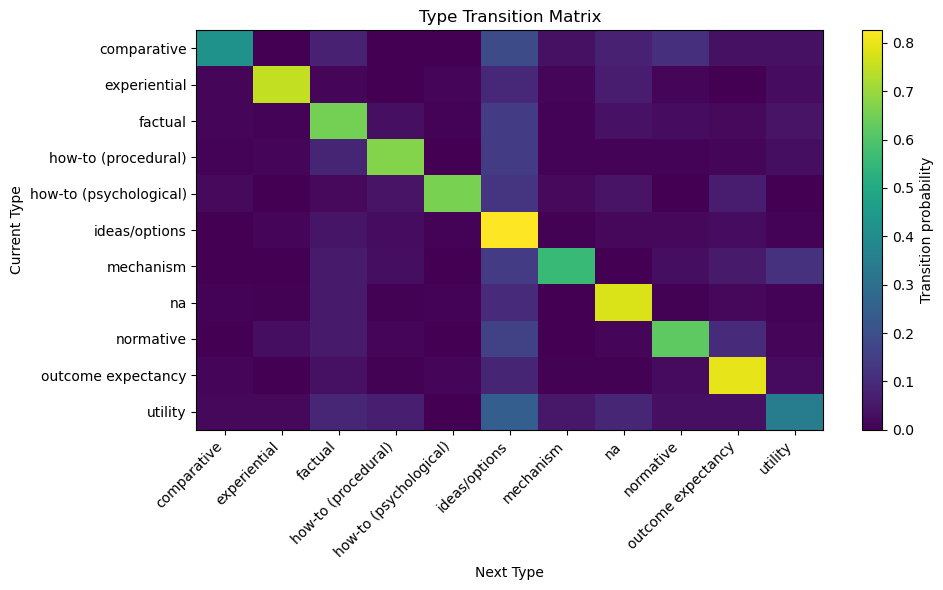

In [11]:
plt.figure(figsize=(10, 6))
plt.imshow(type_matrix_norm, aspect='auto')
plt.xticks(range(len(type_matrix_norm.columns)), type_matrix_norm.columns, rotation=45, ha='right')
plt.yticks(range(len(type_matrix_norm.index)), type_matrix_norm.index)
plt.colorbar(label='Transition probability')
plt.title('Type Transition Matrix')
plt.xlabel('Next Type')
plt.ylabel('Current Type')
plt.tight_layout()
plt.show()

## 7. Most common type transitions

Instead of only looking at the full matrix, we also list the most common transitions directly.

Why we chose to do this:
- It makes interpretation easier.
- It helps identify the strongest behavioral pathways without scanning the whole matrix.
- These top transitions are often the clearest result to report in a write-up.

In [12]:
top_transitions = (
    transition_df
    .groupby(['final_type', 'next_type'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

top_transitions.head(15)

,final_type,next_type,count
51,ideas/options,ideas/options,727
90,outcome expectancy,outcome expectancy,206
19,factual,factual,177
70,na,na,166
31,how-to (procedural),how-to (procedural),87
79,normative,normative,62
9,experiential,experiential,57
48,ideas/options,factual,41
22,factual,ideas/options,39
41,how-to (psychological),how-to (psychological),31


A bar chart makes the strongest transitions even easier to compare visually.

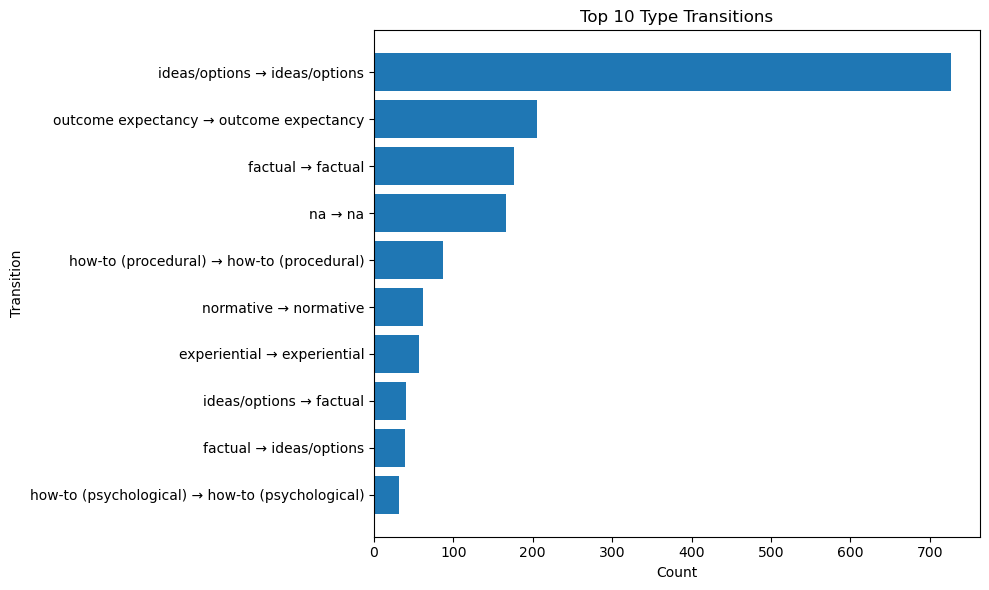

In [13]:
top_plot = top_transitions.head(10).copy().iloc[::-1]
top_plot['transition'] = top_plot['final_type'].astype(str) + ' → ' + top_plot['next_type'].astype(str)

plt.figure(figsize=(10, 6))
plt.barh(top_plot['transition'], top_plot['count'])
plt.title('Top 10 Type Transitions')
plt.xlabel('Count')
plt.ylabel('Transition')
plt.tight_layout()
plt.show()

## 8. Task transitions

We repeat the same logic for **task**.

Why we chose to do this:
- Type captures what kind of information the user wants.
- Task captures what the user is trying to do with that information.
- Transition patterns in task may reveal cognitive progressions such as:
  - learning → deciding
  - deciding → planning

In [14]:
task_matrix = pd.crosstab(transition_df['final_task'], transition_df['next_task'])
task_matrix

next_task,barrier management,evaluation,learn,logistics,na,option seeking,perform
final_task,,,,,,,
barrier management,63,3,7,1,4,11,1
evaluation,2,84,20,2,3,24,3
learn,8,21,556,18,11,81,7
logistics,0,4,11,38,7,12,3
na,3,4,16,1,176,22,2
option seeking,12,19,88,12,19,666,7
perform,1,4,4,3,3,7,18


In [15]:
task_matrix_norm = pd.crosstab(
    transition_df['final_task'],
    transition_df['next_task'],
    normalize='index'
)
task_matrix_norm.round(3)

next_task,barrier management,evaluation,learn,logistics,na,option seeking,perform
final_task,,,,,,,
barrier management,0.700,0.033,0.078,0.011,0.044,0.122,0.011
evaluation,0.014,0.609,0.145,0.014,0.022,0.174,0.022
learn,0.011,0.030,0.792,0.026,0.016,0.115,0.010
logistics,0.000,0.053,0.147,0.507,0.093,0.160,0.040
na,0.013,0.018,0.071,0.004,0.786,0.098,0.009
option seeking,0.015,0.023,0.107,0.015,0.023,0.809,0.009
perform,0.025,0.100,0.100,0.075,0.075,0.175,0.450


## 9. Goal transitions

We also analyze transitions in **goal**.

Why we chose to do this:
- Goal captures the deeper purpose behind the query.
- Even if type or task changes, the goal may remain stable.
- Or, the goal itself may evolve as the user moves closer to a final outcome.

In [16]:
goal_matrix = pd.crosstab(transition_df['final_goal'], transition_df['next_goal'])
goal_matrix

next_goal,action,decision making,motivational reasoning,na,plan
final_goal,,,,,
action,58,10,7,7,33
decision making,14,175,7,4,67
motivational reasoning,8,15,178,5,34
na,3,3,6,163,30
plan,34,65,43,24,1099


In [17]:
goal_matrix_norm = pd.crosstab(
    transition_df['final_goal'],
    transition_df['next_goal'],
    normalize='index'
)
goal_matrix_norm.round(3)

next_goal,action,decision making,motivational reasoning,na,plan
final_goal,,,,,
action,0.504,0.087,0.061,0.061,0.287
decision making,0.052,0.655,0.026,0.015,0.251
motivational reasoning,0.033,0.062,0.742,0.021,0.142
na,0.015,0.015,0.029,0.795,0.146
plan,0.027,0.051,0.034,0.019,0.869


## 10. Full behavior-state transitions

Now we combine `final_type`, `final_task`, and `final_goal` into a single behavioral state.

What we are doing:
- Create one combined label of the form:
  - `type → task → goal`
- Then compute transitions between these full states

Why we chose to do this:
- A single label alone can miss important context.
- Full states let us model richer user pathways.
- This is closer to how human behavior unfolds in practice.

In [18]:
transition_df['behavior_state'] = (
    transition_df['final_type'].astype(str) + ' → ' +
    transition_df['final_task'].astype(str) + ' → ' +
    transition_df['final_goal'].astype(str)
)

transition_df['next_behavior_state'] = transition_df.groupby('participant_no')['behavior_state'].shift(-1)

behavior_transitions = (
    transition_df.dropna(subset=['next_behavior_state'])
    .groupby(['behavior_state', 'next_behavior_state'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

behavior_transitions.head(15)

,behavior_state,next_behavior_state,count
257,ideas/options → option seeking → plan,ideas/options → option seeking → plan,539
308,na → na → na,na → na → na,160
57,factual → learn → plan,factual → learn → plan,124
374,outcome expectancy → learn → motivational reasoning,outcome expectancy → learn → motivational reasoning,90
382,outcome expectancy → learn → plan,outcome expectancy → learn → plan,78
219,ideas/options → option seeking → decision making,ideas/options → option seeking → decision making,50
318,normative → evaluation → decision making,normative → evaluation → decision making,36
132,how-to (procedural) → learn → plan,how-to (procedural) → learn → plan,33
185,ideas/options → learn → plan,ideas/options → learn → plan,30
29,experiential → learn → plan,experiential → learn → plan,25


## 11. Persistence rates

We measure how often the next state stays the same.

Why we chose to do this:
- High persistence means the user tends to remain in the same mode.
- Lower persistence means the user often shifts behavior between adjacent queries.
- This helps distinguish stable behavior from exploratory behavior.

In [19]:
persistence_table = pd.DataFrame({
    'measure': ['same_type_rate', 'same_task_rate', 'same_goal_rate'],
    'value': [
        (transition_df['final_type'] == transition_df['next_type']).mean(),
        (transition_df['final_task'] == transition_df['next_task']).mean(),
        (transition_df['final_goal'] == transition_df['next_goal']).mean()
    ]
})

persistence_table

,measure,value
0,same_type_rate,0.747132
1,same_task_rate,0.765296
2,same_goal_rate,0.799713


## 12. Example transitions from real queries

Finally, we inspect real examples for the most common transitions.

Why we chose to do this:
- It grounds the numeric results in actual user behavior.
- It helps verify that the transitions are meaningful.
- These examples can be very helpful when writing qualitative interpretation.

In [20]:
transition_examples = transition_df.copy()
transition_examples['type_transition'] = (
    transition_examples['final_type'].astype(str) + ' → ' + transition_examples['next_type'].astype(str)
)

top_transition_names = top_transitions.head(3).apply(
    lambda r: f"{r['final_type']} → {r['next_type']}", axis=1
).tolist()

for t in top_transition_names:
    print('\n' + '=' * 80)
    print('Transition:', t)
    display(
        transition_examples.loc[
            transition_examples['type_transition'] == t,
            ['participant_no', 'week_no', 'query', 'final_type', 'next_type', 'final_task', 'next_task', 'final_goal', 'next_goal']
        ].head(5)
    )


Transition: ideas/options → ideas/options


,participant_no,week_no,query,final_type,next_type,final_task,next_task,final_goal,next_goal
0,102,NaN,foods to avoid while losing body fat,ideas/options,ideas/options,option seeking,option seeking,plan,plan
1,102,NaN,foods to avoid while losing body fat,ideas/options,ideas/options,option seeking,option seeking,plan,plan
2,102,NaN,foods to eat that help lose weight,ideas/options,ideas/options,option seeking,option seeking,plan,plan
3,102,NaN,foods to eat that help lose weight,ideas/options,ideas/options,option seeking,option seeking,plan,plan
18,102,NaN,best foods to eat as a woman,ideas/options,ideas/options,option seeking,option seeking,plan,plan



Transition: outcome expectancy → outcome expectancy


,participant_no,week_no,query,final_type,next_type,final_task,next_task,final_goal,next_goal
16,102,NaN,does eating too fast cause weight gain,outcome expectancy,outcome expectancy,learn,learn,decision making,decision making
23,102,NaN,how long do you need to jump rope to lose weight,outcome expectancy,outcome expectancy,logistics,logistics,plan,plan
24,102,NaN,how long do you need to jump rope to lose weight,outcome expectancy,outcome expectancy,logistics,logistics,plan,plan
41,102,NaN,does cleaning your house burn calories,outcome expectancy,outcome expectancy,learn,learn,decision making,decision making
42,102,NaN,does cleaning your house burn calories,outcome expectancy,outcome expectancy,learn,logistics,decision making,plan



Transition: factual → factual


,participant_no,week_no,query,final_type,next_type,final_task,next_task,final_goal,next_goal
60,102,NaN,what happens when you don't eat enough when working out,factual,factual,learn,learn,plan,plan
63,102,NaN,how many calories do you lose in a day,factual,factual,learn,learn,plan,plan
64,102,NaN,how many calories do you lose in a day normally,factual,factual,learn,learn,plan,plan
68,102,NaN,signs of thyroid issues,factual,factual,learn,learn,plan,plan
71,102,NaN,vinyasa yoga,factual,factual,option seeking,logistics,action,motivational reasoning


## 13. Interpretation and takeaways

By the end of this notebook, you should be able to say:

- which kinds of behaviors most often follow others,
- whether users stay in the same mode or shift modes,
- whether there is evidence for decision pipelines such as:
  - fact → recommendation
  - recommendation → decision
- and whether adjacent queries reflect stable exploration, progression, or mixed use.

Overall, this notebook is included because transition analysis gives a much stronger HCI account of AI use: it shows **how behavior unfolds**, not just how often categories appear.